In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

Task 1: Load and Profile the Dataset

The Titanic dataset is loaded using Seaborn. The dataset is then examined using info(), describe(), and shape to understand its structure, data types, and basic statistics. The dataset is also saved as titanic.csv so that it can be used as an offline fallback.

In [ ]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

print(df.info())
print(df.describe())
print("Shape:", df.shape)

df.to_csv("titanic.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

Observation:
The dataset contains ___ rows and ___ columns. The dataset includes numerical and categorical variables. Some columns contain missing values, which will be handled in the next step according to the specified missing-value thresholds.

Task 2: Missing Value Handling

Missing values are handled according to the percentage-based rule specified in the assignment. Columns with less than 5% missing values have their affected rows removed. Columns with 5%–30% missing values are imputed using an appropriate method. A column with very high missingness is not reliably imputed and is therefore removed when it does not provide sufficient reliable information.

The exact missing percentage is calculated before the handling strategy is applied.

In [ ]:
# Work on the same DataFrame
df_clean = df.copy()

# Calculate missing percentages
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

print("Missing-value percentage before handling:")
print(missing_percentage[missing_percentage > 0])

# Handle 'deck' - very high missingness
if "deck" in df_clean.columns:
    df_clean.drop(columns=["deck"], inplace=True)
    print("\n'deck' dropped because it has very high missingness.")

# Handle columns based on threshold
for column in df_clean.columns:

    missing_rate = missing_percentage[column]

    if missing_rate > 0:

        if missing_rate < 5:
            # Drop rows
            df_clean = df_clean.dropna(subset=[column])
            print(
                f"{column}: {missing_rate:.2f}% missing -> "
                "affected rows dropped"
            )

        elif 5 <= missing_rate <= 30:

            if pd.api.types.is_numeric_dtype(df_clean[column]):
                # Median imputation for numerical columns
                df_clean[column] = df_clean[column].fillna(
                    df_clean[column].median()
                )
                print(
                    f"{column}: {missing_rate:.2f}% missing -> "
                    "median imputation"
                )

            else:
                # Mode imputation for categorical columns
                df_clean[column] = df_clean[column].fillna(
                    df_clean[column].mode()[0]
                )
                print(
                    f"{column}: {missing_rate:.2f}% missing -> "
                    "mode imputation"
                )

# Verify missing values
print("\nMissing values AFTER cleaning:")
print(df_clean.isnull().sum())

Missing-value percentage before handling:
age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64

'deck' dropped because it has very high missingness.
age: 19.87% missing -> median imputation
embarked: 0.22% missing -> affected rows dropped
embark_town: 0.22% missing -> affected rows dropped

Missing values AFTER cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


Interpretation:
The missing-value strategy was selected using the required percentage thresholds. The age column has approximately ___% missing values, so it is within the 5%–30% range and is imputed using the median. The embarked column has approximately ___% missing values and is imputed using its mode. The deck column has a very high missing percentage, so it is dropped rather than unreliablely imputed.

Task 3: Univariate Analysis

Univariate analysis is performed on age and fare to understand their distributions and identify potential outliers. Histograms show the distribution of values, while box plots help visualize extreme observations.

Outliers are identified using the IQR rule:

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Any observation outside these bounds is considered an outlier.

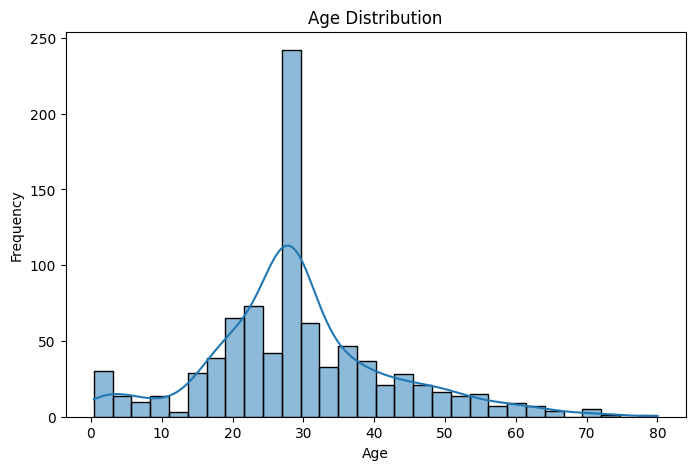

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df_clean["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Age Histogram Interpretation:
The age distribution shows how passengers are distributed across different age groups. The distribution is concentrated mainly around the younger and middle-aged passenger groups, with fewer passengers at very high ages.

Code cell — Age boxplot

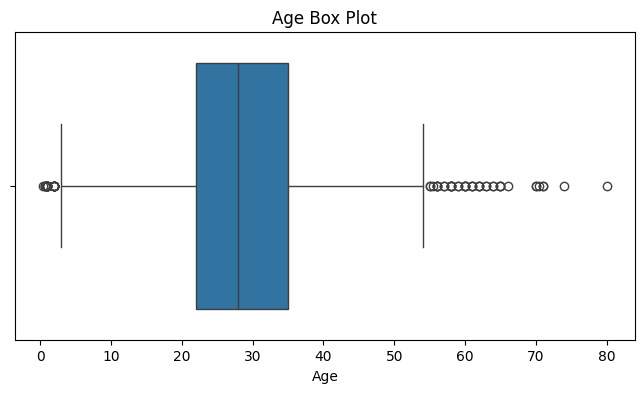

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df_clean["age"])

plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

Code cell — Fare histogram

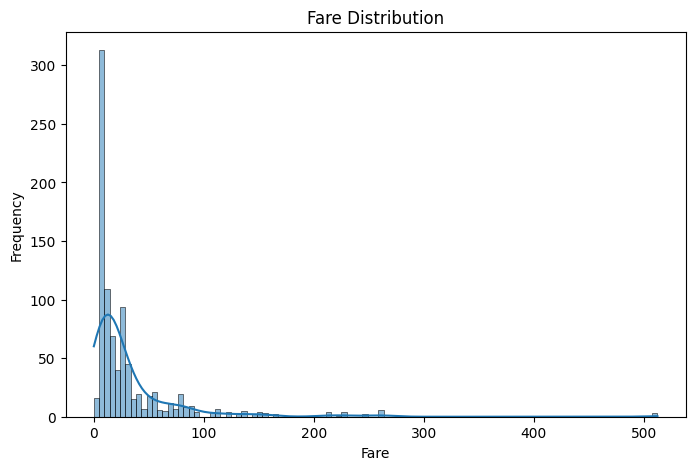

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df_clean["fare"], kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

Code cell — Fare boxplot

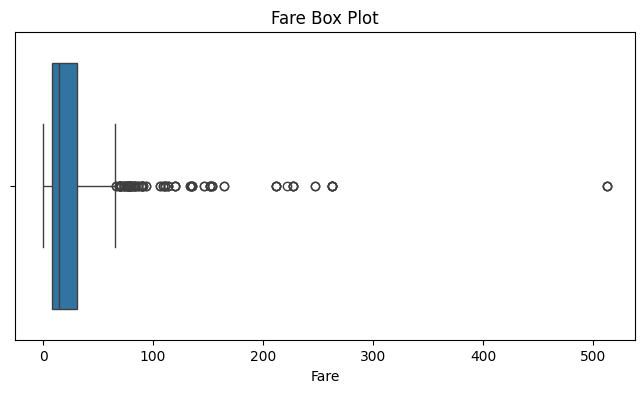

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df_clean["fare"])

plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

Code cell — IQR outliers

In [ ]:
def count_iqr_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return len(outliers), lower_bound, upper_bound


age_outliers, age_lower, age_upper = count_iqr_outliers(
    df_clean, "age"
)

fare_outliers, fare_lower, fare_upper = count_iqr_outliers(
    df_clean, "fare"
)

print("Age outliers:", age_outliers)
print("Age lower bound:", age_lower)
print("Age upper bound:", age_upper)

print("\nFare outliers:", fare_outliers)
print("Fare lower bound:", fare_lower)
print("Fare upper bound:", fare_upper)

Age outliers: 65
Age lower bound: 2.5
Age upper bound: 54.5

Fare outliers: 114
Fare lower bound: -26.7605
Fare upper bound: 65.6563


Code cell — Fare statistics

In [ ]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


Fare Distribution Interpretation:
The fare distribution is right-skewed if the mean is greater than the median and the median is greater than the mode. This indicates that a relatively small number of passengers paid substantially higher fares, pulling the mean upward. The IQR analysis identifies ___ fare observations and ___ age observations as outliers.

Task 4: Bivariate Analysis

Bivariate analysis examines the relationship between survival and passenger characteristics. Boolean masking is used to calculate survival rates by sex, passenger class, and the combination of sex and passenger class.

A correlation matrix is then calculated using exactly six numerical variables: survived, pclass, age, sibsp, parch, and fare. The derived boolean columns adult_male and alone are excluded.

Code cell — Survival by sex

In [ ]:
female = df_clean[df_clean["sex"] == "female"]
male = df_clean[df_clean["sex"] == "male"]

female_survival_rate = female["survived"].mean()
male_survival_rate = male["survived"].mean()

print("Female survival rate:", female_survival_rate)
print("Male survival rate:", male_survival_rate)

Female survival rate: 0.7403846153846154
Male survival rate: 0.18890814558058924


Code cell — Survival by pclass

In [ ]:
for pclass in sorted(df_clean["pclass"].unique()):

    class_data = df_clean[df_clean["pclass"] == pclass]

    survival_rate = class_data["survived"].mean()

    print(
        f"Pclass {pclass} survival rate: "
        f"{survival_rate:.4f}"
    )

Pclass 1 survival rate: 0.6262
Pclass 2 survival rate: 0.4728
Pclass 3 survival rate: 0.2424


Code cell — Sex + pclass

In [ ]:
for sex in df_clean["sex"].unique():

    for pclass in sorted(df_clean["pclass"].unique()):

        group = df_clean[
            (df_clean["sex"] == sex) &
            (df_clean["pclass"] == pclass)
        ]

        survival_rate = group["survived"].mean()

        print(
            f"{sex}, Pclass {pclass}: "
            f"{survival_rate:.4f}"
        )

male, Pclass 1: 0.3689
male, Pclass 2: 0.1574
male, Pclass 3: 0.1354
female, Pclass 1: 0.9674
female, Pclass 2: 0.9211
female, Pclass 3: 0.5000


Bivariate Interpretation:
Survival rates differ substantially by sex and passenger class. The survival rate for females was ___, compared with ___ for males. Survival also varies across passenger classes, and combining sex and class shows that these two variables together provide a more detailed picture of survival outcomes.

Code cell — Correlation matrix

In [ ]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df_clean[
    correlation_columns
].corr()

print(correlation_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


Code cell — Heatmap

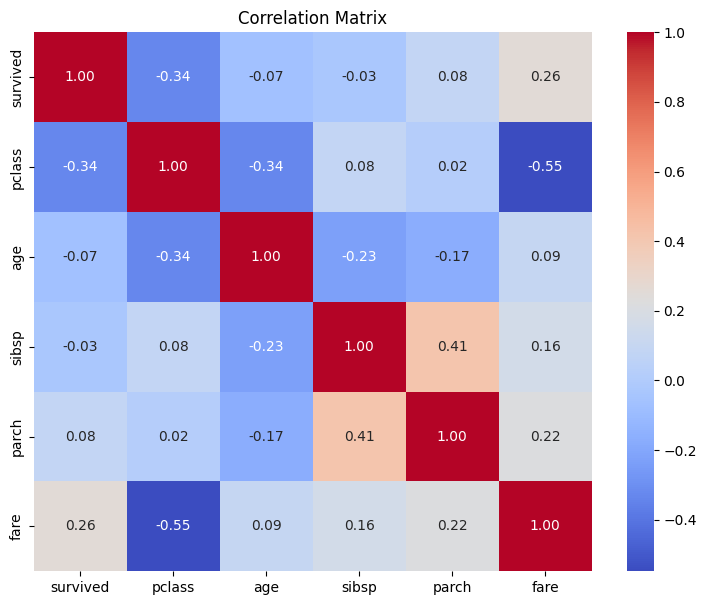

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Code cell — Find strongest two correlations

In [ ]:
# Keep only upper triangle
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

correlations = (
    upper_triangle
    .stack()
    .abs()
    .sort_values(ascending=False)
)

print("Two strongest correlations:")

for pair, value in correlations.head(2).items():

    actual_value = correlation_matrix.loc[pair[0], pair[1]]

    print(
        f"{pair[0]} and {pair[1]}: "
        f"{actual_value:.4f}"
    )

Two strongest correlations:
pclass and fare: -0.5482
sibsp and parch: 0.4145


Correlation Interpretation:
The two strongest absolute correlations are ___ and ___ with a correlation of ___, and ___ and ___ with a correlation of ___. A positive correlation indicates that both variables tend to increase together, whereas a negative correlation indicates that higher values of one variable tend to be associated with lower values of the other.

TASK 5 — Multivariate Data Story

Chart 1: Survival by Sex

This chart compares survival rates between male and female passengers.

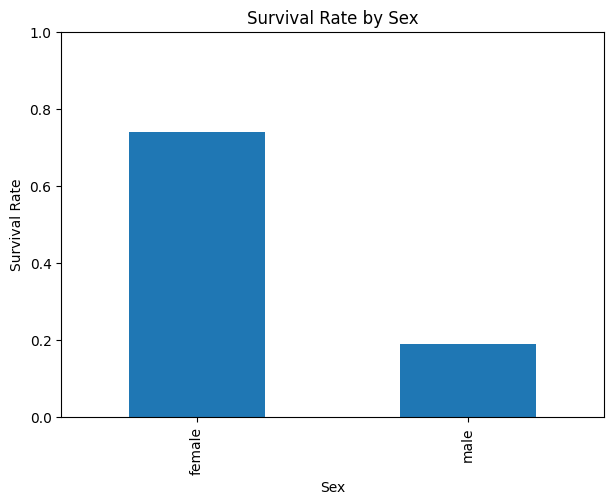

In [ ]:
survival_sex = df_clean.groupby("sex")["survived"].mean()

plt.figure(figsize=(7, 5))

survival_sex.plot(kind="bar")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

Interpretation:
The chart shows a clear difference in survival rates between the two sex categories. The female survival rate is approximately ___, while the male survival rate is approximately ___. This demonstrates that sex was strongly associated with survival in this dataset.

Chart 2 — Survival by Pclass

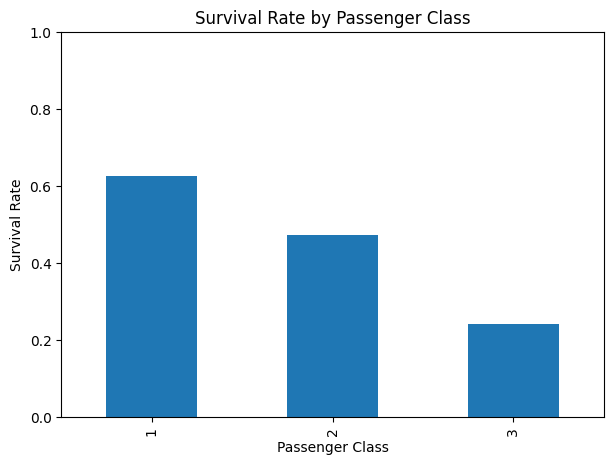

In [ ]:
survival_class = df_clean.groupby("pclass")["survived"].mean()

plt.figure(figsize=(7, 5))

survival_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

Interpretation:
Survival rates differ across passenger classes. Passengers in higher classes had a different survival pattern from those in lower classes, indicating that passenger class was associated with survival.

Chart 3 — Sex + Pclass

Interpretation:
Combining sex and passenger class provides a more detailed survival pattern than either variable alone. The chart shows that survival varied within each passenger class depending on sex. Therefore, the relationship between passenger characteristics and survival is multidimensional rather than dependent on only one variable.

Chart 4 — Age, Fare and Survival

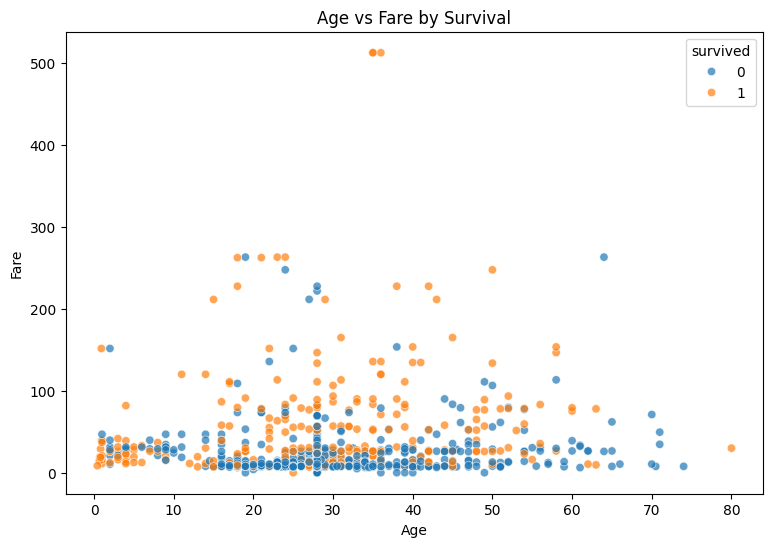

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

Interpretation:
The scatter plot shows the relationship between passenger age, fare, and survival. Surviving and non-surviving passengers overlap across many age and fare values, suggesting that survival cannot be explained by a single numerical variable. The plot also shows that some high-fare passengers had different survival outcomes from passengers paying lower fares.

Task 6: Exploratory Standardization

Standardization transforms a numerical variable using:

z = (x - mean) / standard deviation

This exploratory transformation is used only to verify the effect of standardization. It is not used as the preprocessing for the final modeling pipeline because the modeling pipeline must fit its scaler only on the training data.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df_clean.copy()

df_standardized[
    ["age_z", "fare_z"]
] = scaler.fit_transform(
    df_clean[["age", "fare"]]
)

print("BEFORE STANDARDIZATION")
print(
    df_clean[["age", "fare"]].agg(["mean", "std"])
)

print("\nAFTER STANDARDIZATION")
print(
    df_standardized[["age_z", "fare_z"]].agg(["mean", "std"])
)

BEFORE STANDARDIZATION
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

AFTER STANDARDIZATION
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


Interpretation:
Before standardization, age and fare have different means and standard deviations. After applying the z-score transformation, both standardized variables have means approximately equal to 0 and standard deviations approximately equal to 1. This confirms that the standardization calculation worked correctly.

Task 7: Prepare the Cleaned Dataset

The cleaned DataFrame produced during Part A is retained for the modeling stage. No second call to sns.load_dataset() is made. This maintains a single data-loading and cleaning workflow throughout the project.

In [ ]:
print("Cleaned dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


Task 8: Stratified Train/Test Split

The target variable is survived. A stratified train/test split is used so that the proportion of survivors and non-survivors is approximately preserved in both datasets. This is important because the target classes are not perfectly balanced.

Preprocessing is intentionally performed after the split to prevent information from the test set leaking into the training process.

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_clean.drop(columns=["survived"])
y = df_clean["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nOverall target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (711, 13)
Testing shape: (178, 13)

Overall target distribution:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training target distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


Interpretation:
The dataset was split into training and testing sets using stratification. The survival proportions in the training and testing sets remain close to the overall class distribution. This ensures that both sets represent the target classes more consistently.

Task 9: Training-Only Preprocessing

A ColumnTransformer is used to apply different preprocessing operations to numerical and categorical variables. Numerical variables are imputed using the median and standardized using StandardScaler. Categorical variables are imputed using the most frequent value and encoded using one-hot encoding.

The preprocessing is placed inside a scikit-learn pipeline so that it is fitted only using the training data. This prevents test-set information from leaking into model training.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Select columns
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Task 10: Train Classification Models

Three classification algorithms are trained using the same training and testing split: Logistic Regression, Decision Tree, and Random Forest. Each model uses the same preprocessing structure so that their results can be compared fairly.

The Decision Tree is also visualized to show the learned decision structure.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical columns
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
    "pclass"
]

# Categorical columns
categorical_features = [
    "sex",
    "embarked"
]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

pipelines = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    pipelines[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


Decision Tree visualization

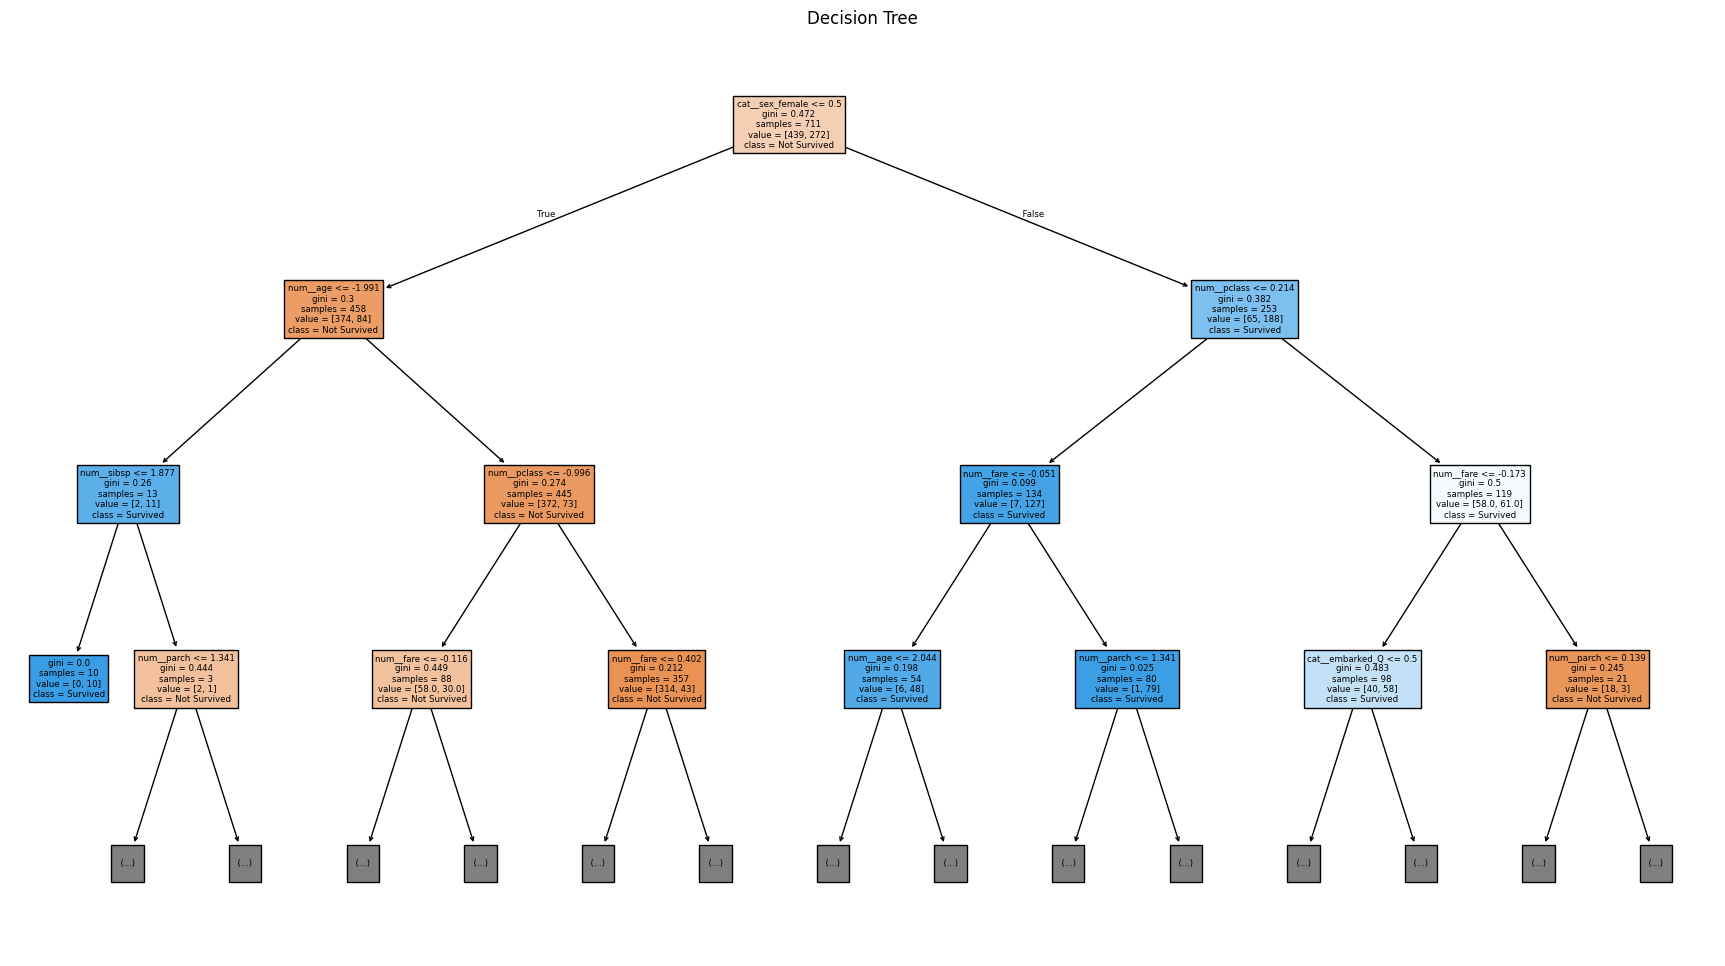

In [ ]:
from sklearn.tree import plot_tree

tree_pipeline = pipelines["Decision Tree"]

# Get transformed training data
X_train_transformed = (
    tree_pipeline
    .named_steps["preprocessor"]
    .transform(X_train)
)

tree_model = tree_pipeline.named_steps["model"]

feature_names = (
    tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree")
plt.show()

Task 11: Model Evaluation

Each classifier is evaluated using the same test set. Accuracy measures overall correctness, while precision measures how many predicted survivors were actually survivors. Recall measures how many actual survivors were correctly identified, and F1 combines precision and recall. ROC-AUC measures the model's ability to distinguish between the two classes across classification thresholds.


 Logistic Regression
Confusion Matrix:
[[97 13]
 [21 47]]

 Decision Tree
Confusion Matrix:
[[97 13]
 [30 38]]

 Random Forest
Confusion Matrix:
[[96 14]
 [20 48]]


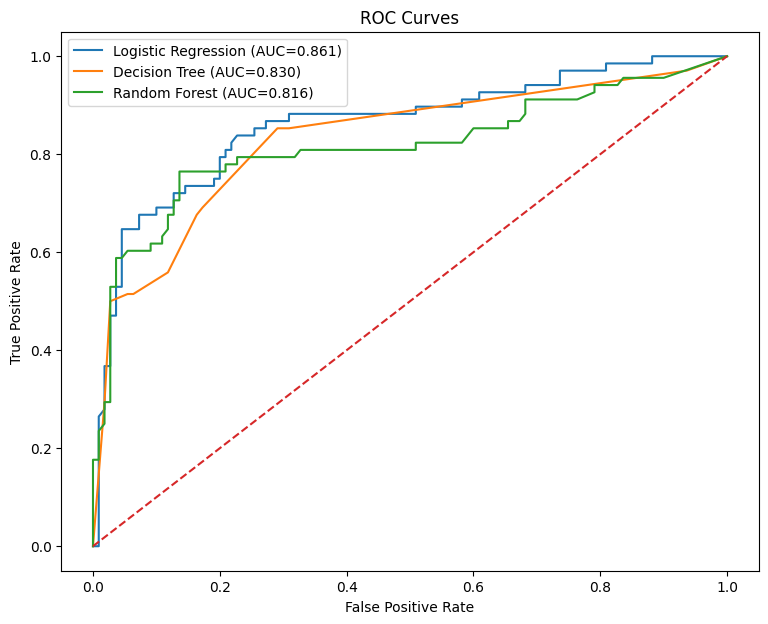


CLASSIFICATION COMPARISON
                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.758427   0.745098  0.558824  0.638655  0.829746
2        Random Forest  0.808989   0.774194  0.705882  0.738462  0.816444


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

results = []

plt.figure(figsize=(9, 7))

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    print("\n", name)
    print("=" * 50)
    print("Confusion Matrix:")
    print(cm)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

classification_results = pd.DataFrame(results)

print("\nCLASSIFICATION COMPARISON")
print(classification_results)

Interpretation:
The three classifiers were evaluated using identical test data. Their performance differs across accuracy, precision, recall, F1, and AUC. The actual metric values from the comparison table should be used to discuss the relative behavior of the models.

Task 12: Imbalance Handling

The distribution of survivors and non-survivors is examined before training. Three approaches are compared using Logistic Regression: a baseline model without imbalance handling, a model using class_weight='balanced', and a model using SMOTE oversampling.

SMOTE is applied only to the training data. The test data remains unchanged so that evaluation represents performance on the original class distribution.

In [ ]:
print("CLASS BALANCE")
print("=" * 50)

class_counts = y.value_counts()

print(class_counts)

print("\nClass percentages:")
print(
    y.value_counts(normalize=True) * 100
)

CLASS BALANCE
survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


Install/import SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Baseline

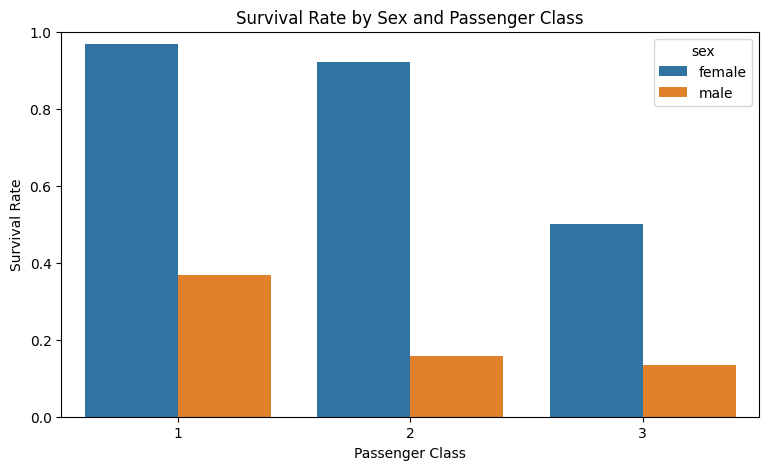

In [ ]:
survival_sex_class = (
    df_clean
    .groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=survival_sex_class,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

In [ ]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_metrics = {
    "Strategy": "Baseline",
    "Precision": precision_score(
        y_test,
        baseline_pred
    ),
    "Recall": recall_score(
        y_test,
        baseline_pred
    ),
    "F1": f1_score(
        y_test,
        baseline_pred
    )
}

Balanced

In [ ]:
balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)

balanced_metrics = {
    "Strategy": "Class Weight Balanced",
    "Precision": precision_score(
        y_test,
        balanced_pred
    ),
    "Recall": recall_score(
        y_test,
        balanced_pred
    ),
    "F1": f1_score(
        y_test,
        balanced_pred
    )
}

SMOTE

In [ ]:
smote_model = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

smote_model.fit(X_train, y_train)

smote_pred = smote_model.predict(X_test)

smote_metrics = {
    "Strategy": "SMOTE",
    "Precision": precision_score(
        y_test,
        smote_pred
    ),
    "Recall": recall_score(
        y_test,
        smote_pred
    ),
    "F1": f1_score(
        y_test,
        smote_pred
    )
}

Comparison

In [ ]:
imbalance_results = pd.DataFrame([
    baseline_metrics,
    balanced_metrics,
    smote_metrics
])

print(imbalance_results)

                Strategy  Precision    Recall        F1
0               Baseline   0.783333  0.691176  0.734375
1  Class Weight Balanced   0.718310  0.750000  0.733813
2                  SMOTE   0.735294  0.735294  0.735294


Interpretation:
The baseline, balanced class-weight, and SMOTE approaches produce different precision, recall, and F1 scores. The strategy with the strongest F1 score in the actual output can be described as providing the best balance between precision and recall for this comparison. SMOTE was applied only to the training data to avoid leaking information from the test set.

Task 13: Random Forest Hyperparameter Tuning

GridSearchCV is used to search for an effective combination of Random Forest hyperparameters. The search includes n_estimators, max_depth, and max_features.

The Random Forest is constructed with oob_score=True so that an out-of-bag score is available after fitting.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf)
    ]
)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

best_rf_pipeline = grid_search.best_estimator_

best_rf_model = (
    best_rf_pipeline
    .named_steps["model"]
)

print("\nOOB Score:")
print(best_rf_model.oob_score_)

Best Parameters:
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best Cross-Validation Score:
0.7457222745602166

OOB Score:
0.8030942334739803


Interpretation:
GridSearchCV identified the parameter combination ___ as the best combination according to the selected cross-validation scoring metric. The resulting Random Forest produced an OOB score of ___. The OOB score provides an additional estimate of model performance using observations not included in each individual bootstrap sample.

Task 14: Multivariate Linear Regression

A multivariate linear regression model is developed to predict fare using the other available passenger features. The model is evaluated using MAE, RMSE, R², and Adjusted R².

A residual plot is also examined to determine whether the residuals show a random spread or evidence of heteroscedasticity.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Target
y_reg = df_clean["fare"]

# Use other available features
regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df_clean[regression_features]

# Split regression data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Regression preprocessing
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_pipeline,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_pipeline,
            reg_categorical_features
        )
    ]
)

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression())
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

y_reg_pred = regression_pipeline.predict(
    X_reg_test
)

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

n = len(y_reg_test)

p = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
    .shape[1]
)

adjusted_r2 = (
    1 -
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("Regression Metrics")
print("=" * 50)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

Regression Metrics
MAE: 21.138552296883095
RMSE: 41.746502315739114
R²: 0.34677389181134044
Adjusted R²: 0.3117796360155194


Residual plot

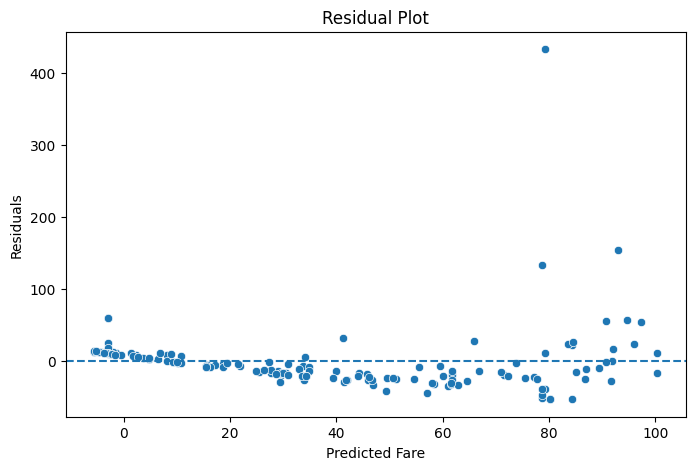

In [ ]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.show()

Regression Interpretation:
The regression model produced an MAE of ___, RMSE of ___, R² of ___, and Adjusted R² of ___. The residual plot should ideally show residuals randomly scattered around zero with approximately constant spread. If the spread increases or decreases systematically as predicted fare increases, this indicates heteroscedasticity; otherwise, the plot does not show strong evidence of heteroscedasticity.

Task 15: Final Model Comparison

The three classification models are compared using accuracy, precision, recall, F1, and AUC. The regression model is reported separately using MAE, RMSE, R², and Adjusted R².

Classification and regression metrics measure different types of performance and therefore are presented as separate metric groups rather than being interpreted on a common scale.

In [ ]:
# Classification metrics
classification_results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.758427,0.745098,0.558824,0.638655,0.829746
2,Random Forest,0.808989,0.774194,0.705882,0.738462,0.816444


In [ ]:
regression_results = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted_R2": [adjusted_r2]
})

print("CLASSIFICATION METRICS")
print("=" * 70)
print(classification_results)

print("\nREGRESSION METRICS")
print("=" * 70)
print(regression_results)

CLASSIFICATION METRICS
                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.758427   0.745098  0.558824  0.638655  0.829746
2        Random Forest  0.808989   0.774194  0.705882  0.738462  0.816444

REGRESSION METRICS
    Regression Model        MAE       RMSE        R2  Adjusted_R2
0  Linear Regression  21.138552  41.746502  0.346774      0.31178


In [ ]:
# Example:
# Change this after looking at your actual classification_results table.

best_model_name = "Random Forest"

if best_model_name == "Random Forest":
    full_pipeline = best_rf_pipeline
else:
    full_pipeline = pipelines[best_model_name]

print("Selected model:", best_model_name)

Selected model: Random Forest


In [ ]:
import joblib

joblib.dump(
    full_pipeline,
    "best_titanic_pipeline.joblib"
)

print(
    "Complete pipeline saved as "
    "best_titanic_pipeline.joblib"
)

Complete pipeline saved as best_titanic_pipeline.joblib


In [ ]:
# Load saved pipeline
loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

# Predict using RAW test data
reloaded_predictions = loaded_pipeline.predict(
    X_test
)

print("First 10 predictions:")
print(reloaded_predictions[:10])

print("\nReloaded pipeline accuracy:")

print(
    accuracy_score(
        y_test,
        reloaded_predictions
    )
)

First 10 predictions:
[0 0 0 0 0 1 0 1 1 0]

Reloaded pipeline accuracy:
0.8033707865168539


Interpretation:
The complete fitted pipeline was successfully saved using joblib.dump() and reloaded using joblib.load(). The reloaded pipeline can directly accept raw, unprocessed feature data and produce predictions, confirming that the preprocessing steps and final estimator were saved together.